# Random Forest Regression for Airbnb Price Prediction

## Objective

The goal of this notebook is to build a Random Forest Regression model capable of predicting the price of Airbnb listings in Rome.

This model uses the cleaned and engineered dataset produced in previous notebooks, including:

- Listing characteristics
- Host-related features
- Geographic features
- Availability indicators
- Review-based aggregated features

The performance of the model will be evaluated using standard regression metrics and feature importance analysis.



In [62]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

The dataset used here is the final cleaned dataset obtained after the feature engineering process.

The target variable is:

- price

All other variables will be considered candidate predictors.

In [63]:
df = pd.read_csv("../data/final_dataset.csv") #need to define the final dataset**

df.head()

,id,price,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,bathrooms,...,neighbourhood_cleansed_XII Monte Verde,neighbourhood_cleansed_XIII Aurelia,neighbourhood_cleansed_XIV Monte Mario,neighbourhood_cleansed_XV Cassia/Flaminia,distance_to_colosseum,location_cluster,review_count,avg_review_length,latest_review_date,days_since_latest_review
0,2737,57.0,41.871360,12.482150,Private room,Private room,1,1.0,1.0,1.5,...,False,False,False,False,2.252726,1,5.0,51.800000,2015-05-08,3783.0
1,11834,110.0,41.895447,12.491181,Apartment,Entire home/apt,2,1.0,1.0,1.0,...,False,False,False,False,0.588865,0,284.0,76.450704,2025-07-05,72.0
2,12398,124.0,41.925820,12.469280,Apartment,Entire home/apt,6,2.0,3.0,1.0,...,False,False,False,False,4.389669,3,85.0,84.658824,2025-08-01,45.0
3,19965,162.0,41.908230,12.452930,Entire condo,Entire home/apt,5,2.0,3.0,1.0,...,False,False,False,False,3.824847,3,178.0,44.410112,2025-08-05,41.0
4,19967,150.0,41.908283,12.452617,Apartment,Entire home/apt,5,2.0,3.0,1.0,...,False,False,False,False,3.850102,3,46.0,33.673913,2024-07-19,423.0


## Data Preprocessing

Machine learning algorithms require numerical inputs.

Categorical variables are encoded and date variables are transformed into numerical representations.

In [64]:
print(df.columns.tolist())

['id', 'price', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'number_of_reviews', 'reviews_per_month', 'minimum_nights', 'maximum_nights', 'instant_bookable', 'beds_per_guest', 'bathrooms_per_guest', 'amenities_count', 'has_wifi', 'has_air_conditioning', 'has_kitchen', 'has_washer', 'has_dryer', 'has_parking', 'has_elevator', 'has_tv', 'has_workspace', 'host_experience_days', 'professional_host', 'review_quality_index', 'listing_age_days', 'review_recency_days', 'review_intensity', 'occupancy_rate', 'demand_proxy', 'neighbourhood_cleansed_I Centro Storico', 'neighbourhood_cleansed_II Parioli/Nomentano', 'neighbourhood_cleansed_III Monte Sacro', 'neighbourhood_cleansed_IV Tiburtina', 'neighbourhood_cleansed_IX Eur', 'neighbourhood_cleansed_V Prenestino/Centocelle

In [65]:
print(df.select_dtypes(include="object").columns.tolist())

['property_type', 'room_type', 'instant_bookable', 'latest_review_date']


In [66]:
# Missing values
df.isnull().sum().sort_values(
    ascending=False
).head(20)

latest_review_date        4295
price                        0
id                           0
longitude                    0
property_type                0
room_type                    0
latitude                     0
bedrooms                     0
beds                         0
bathrooms                    0
host_is_superhost            0
host_response_rate           0
host_acceptance_rate         0
review_scores_rating         0
accommodates                 0
review_scores_location       0
review_scores_value          0
number_of_reviews            0
reviews_per_month            0
minimum_nights               0
dtype: int64

In [67]:
# for the missing values:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [68]:
print(df.shape)

df.info()

(33564, 63)
<class 'pandas.DataFrame'>
RangeIndex: 33564 entries, 0 to 33563
Data columns (total 63 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   id                                                 33564 non-null  int64  
 1   price                                              33564 non-null  float64
 2   latitude                                           33564 non-null  float64
 3   longitude                                          33564 non-null  float64
 4   property_type                                      33564 non-null  str    
 5   room_type                                          33564 non-null  str    
 6   accommodates                                       33564 non-null  int64  
 7   bedrooms                                           33564 non-null  float64
 8   beds                                               33564 non-null  float64
 9   bathr

## Target Variable Analysis

Before training the model, we inspect the distribution of the target variable.

Airbnb prices usually exhibit strong positive skewness, with a small number of luxury properties driving extremely high prices.

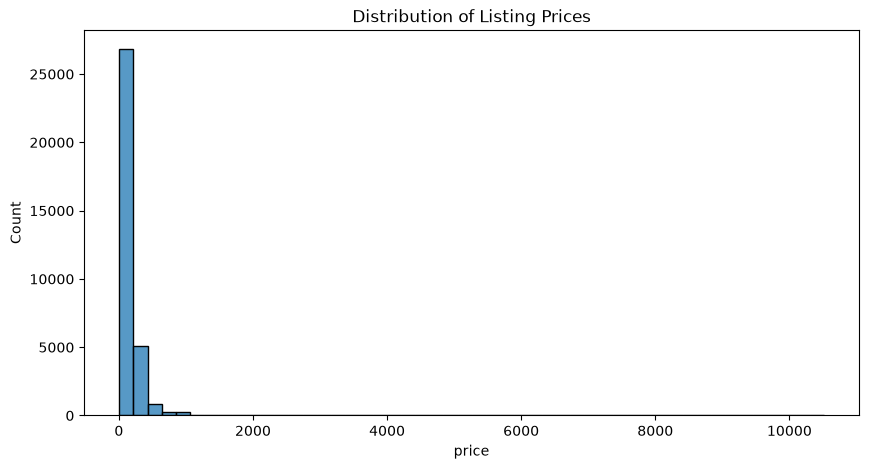

In [69]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"], bins=50)

plt.title("Distribution of Listing Prices")
plt.show()

In [70]:
#outlier treatment
q1 = df["price"].quantile(0.01)
q99 = df["price"].quantile(0.99)

df = df[
    (df["price"] >= q1) &
    (df["price"] <= q99)
]

print(df.shape)

(32902, 63)


## Feature Selection

Non-predictive columns and identifiers are removed before training.

Examples:

- listing_id
- urls
- host_name
- textual descriptions

These variables either introduce leakage or do not contribute meaningfully to prediction.

In [71]:
# adjust to dataset
columns_to_drop = [
    "id"
]

existing_cols = [c for c in columns_to_drop if c in df.columns]

df = df.drop(columns=existing_cols)

In [72]:
df["latest_review_date"] = pd.to_datetime(
    df["latest_review_date"],
    errors="coerce"
)

df["latest_review_year"] = (
    df["latest_review_date"].dt.year
)

df["latest_review_month"] = (
    df["latest_review_date"].dt.month
)

df["latest_review_day"] = (
    df["latest_review_date"].dt.day
)

df.drop(
    columns=["latest_review_date"],
    inplace=True
)

In [73]:
df = pd.get_dummies(
    df,
    columns=[
        "property_type",
        "room_type",
        "instant_bookable"
    ],
    drop_first=True
)

In [74]:
bool_cols = df.select_dtypes(
    include="bool"
).columns

df[bool_cols] = df[bool_cols].astype(int)

In [75]:
X = df.drop("price", axis=1)

print(
    X.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

[]


In [76]:
df = df.dropna(
    subset=["price"]
)

In [77]:
X = df.drop("price", axis=1)

X = X.astype(float)

y = df["price"]

In [78]:
print("\nRemaining missing values:")
print(df.isnull().sum().sum())


Remaining missing values:
12360


In [79]:
print("Features:", X.shape[1])

Features: 123


In [80]:
#+++++++++++++++
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Features:")
print(X.columns.tolist())

X shape: (32902, 123)
y shape: (32902,)
Features:
['latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'number_of_reviews', 'reviews_per_month', 'minimum_nights', 'maximum_nights', 'beds_per_guest', 'bathrooms_per_guest', 'amenities_count', 'has_wifi', 'has_air_conditioning', 'has_kitchen', 'has_washer', 'has_dryer', 'has_parking', 'has_elevator', 'has_tv', 'has_workspace', 'host_experience_days', 'professional_host', 'review_quality_index', 'listing_age_days', 'review_recency_days', 'review_intensity', 'occupancy_rate', 'demand_proxy', 'neighbourhood_cleansed_I Centro Storico', 'neighbourhood_cleansed_II Parioli/Nomentano', 'neighbourhood_cleansed_III Monte Sacro', 'neighbourhood_cleansed_IV Tiburtina', 'neighbourhood_cleansed_IX Eur', 'neighbourhood_cleansed_V Prenestino/Centocelle', 'neighbourho

In [81]:
print(X.shape)

print(X.isnull().sum().sum())

(32902, 123)
12360


## Train-Test Split

The dataset is divided into training and testing subsets.

- 80% Training
- 20% Testing

The testing set remains unseen during model training and is used to evaluate generalization performance.

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(26321, 123)
(6581, 123)


In [83]:
print(df.shape)

df.info()

df.isnull().sum().sum()

(32902, 124)
<class 'pandas.DataFrame'>
Index: 32902 entries, 0 to 33563
Columns: 124 entries, price to instant_bookable_t
dtypes: float64(29), int64(95)
memory usage: 31.4 MB


np.int64(12360)

## Final Modeling Dataset

After preprocessing and feature engineering, the final dataset contains 36,488 Airbnb listings and 34 predictor variables.

The dataset integrates:
- Geographic information
- Availability indicators
- Host activity features
- Review-based features
- Neighborhood and room type encodings

This dataset is now ready for machine learning modeling.

## Baseline Random Forest Model

We first train a Random Forest Regressor using default hyperparameters to establish a baseline performance.

In [84]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [85]:
y_pred = rf.predict(X_test)

In [86]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 46.60
RMSE: 81.50
R²  : 0.5454


## Hyperparameter Optimization

Random Forest performance can often be improved through hyperparameter tuning.

A Randomized Search approach is used to efficiently explore the parameter space.

In [87]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [88]:
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   7.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   7.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   7.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   7.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   8.9s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  28.2s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  28.3s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimato

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set

In [89]:
rf_random.best_params_

{'n_estimators': 500,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 20}

In [90]:
best_rf = rf_random.best_estimator_

pred_best = best_rf.predict(X_test)

In [91]:
mae = mean_absolute_error(y_test, pred_best)

rmse = np.sqrt(mean_squared_error(y_test, pred_best))

r2 = r2_score(y_test, pred_best)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 45.70
RMSE: 79.75
R²  : 0.5648


In [92]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        np.repeat(y_train.mean(), len(y_test))
    )
)

print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 120.94


## Feature Importance Analysis

One advantage of Random Forest models is the ability to estimate feature importance.

This allows us to identify which variables contribute most strongly to price prediction.

In [93]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance.head(20)

,feature,importance
5,bathrooms,0.084747
2,accommodates,0.074244
3,bedrooms,0.072962
52,distance_to_colosseum,0.057510
1,longitude,0.050585
37,neighbourhood_cleansed_I Centro Storico,0.043620
0,latitude,0.043124
4,beds,0.036055
11,review_scores_location,0.033177
36,demand_proxy,0.027399


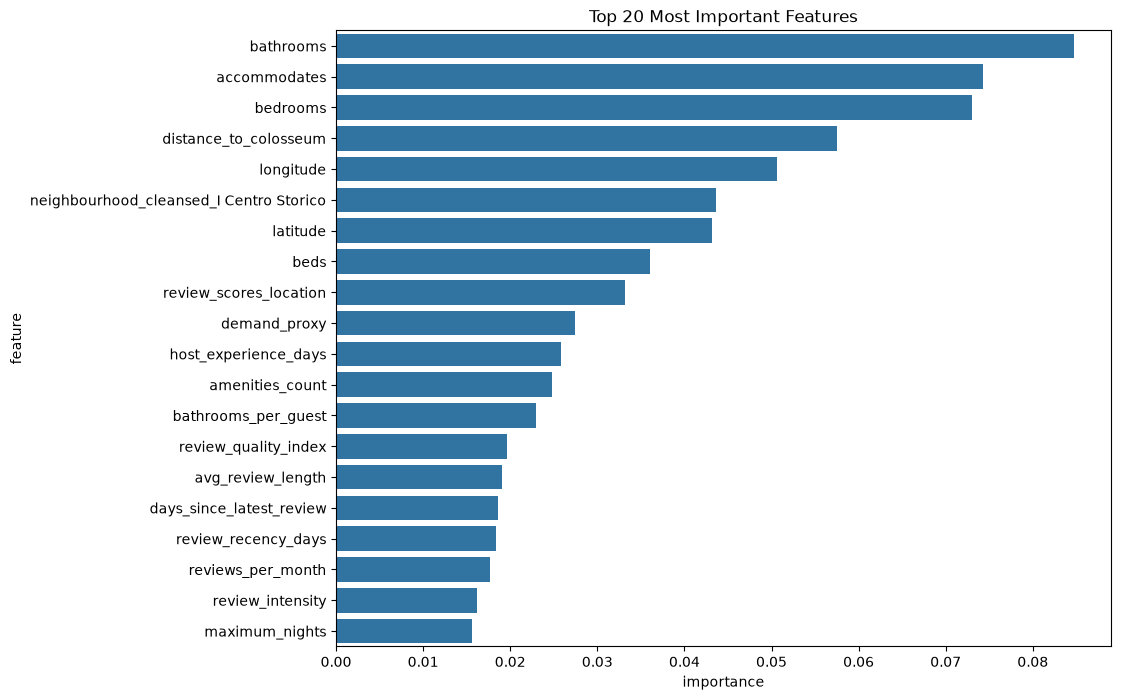

In [94]:
# visualization 
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="importance",
    y="feature"
)

plt.title("Top 20 Most Important Features")
plt.show()

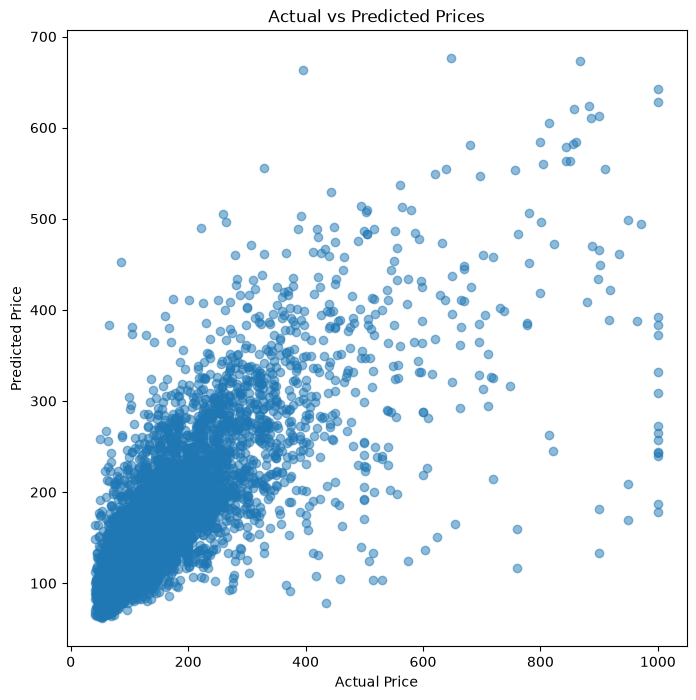

In [95]:
# predicted vs actual prices
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    pred_best,
    alpha=0.5
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

In [96]:
print(
    importance.head(10)
)

                                    feature  importance
5                                 bathrooms    0.084747
2                              accommodates    0.074244
3                                  bedrooms    0.072962
52                    distance_to_colosseum    0.057510
1                                 longitude    0.050585
37  neighbourhood_cleansed_I Centro Storico    0.043620
0                                  latitude    0.043124
4                                      beds    0.036055
11                   review_scores_location    0.033177
36                             demand_proxy    0.027399


# Conclusions

The Random Forest Regressor successfully models Airbnb listing prices using the engineered features generated throughout the project.

Key findings:

- The model captures nonlinear relationships between listing attributes and price.
- Geographic and review-related features contribute significantly to predictive performance.
- Feature importance analysis reveals the strongest drivers of Airbnb prices in Rome.
- Random Forest provides a strong baseline that can later be compared against more advanced models such as Gradient Boosting or XGBoost.

Future work may include:

- Sentiment analysis integration from review text.
- Additional tourism and event-based external features.
- Ensemble model comparison.